<a href="https://colab.research.google.com/github/KurniaYufi/nlp-sentiment-analisis/blob/main/TF-IDF%20Homework/1B_TFIDF_Danantara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dependencies

In [1]:
import nltk
import math
import matplotlib.pyplot as plt
import pandas as pd
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Define Document

In [2]:
sentence = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola's side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

# Text Preprocessing

In [3]:
# Sentence tokenization
sent_token = sent_tokenize(sentence)
print(sent_token)

['\nManchester City makes history by winning Club World Cup\n\nManchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.', "Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola's side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.", 'The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.', '“We’ve shown over the past 12 months we are the best team in the world.', 'Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.', '“To win these five trophies – for me, the five biggest prizes available to us – is incredible.', 'I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.', 'I cou

In [4]:
# Training TF-IDF Vectorizer on sentences (English stop words)
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(sent_token)
feature_names = vectorizer.get_feature_names_out()

print("Shape of the Feature Matrix (sentences, unique words):", features.shape)
print("\nFeature Names (vocabulary):", feature_names)

Shape of the Feature Matrix (sentences, unique words): (20, 183)

Feature Names (vocabulary): ['12' '40' '72nd' '88th' 'according' 'achieved' 'aké' 'alongside'
 'amazing' 'arabia' 'ask' 'attempted' 'available' 'best' 'better'
 'biggest' 'boasts' 'boss' 'brazilian' 'break' 'brilliant' 'broke'
 'calendar' 'came' 'cannoned' 'capped' 'captain' 'champion' 'champions'
 'charged' 'chest' 'city' 'clinical' 'close' 'club' 'completed'
 'consistency' 'continued' 'corner' 'couldn' 'cross' 'cup' 'currently'
 'dangerous' 'defence' 'defender' 'deflected' 'dismantling' 'distance'
 'dominance' 'doubled' 'effort' 'ended' 'england' 'english' 'everton'
 'exchanges' 'fa' 'face' 'faces' 'fans' 'far' 'fight' 'final' 'finish'
 'fixture' 'fluminense' 'foden' 'forward' 'fourth' 'free' 'friday' 'game'
 'got' 'guardiola' 'having' 'heads' 'highly' 'history' 'hold' 'home'
 'honestly' 'honour' 'incredible' 'jigsaw' 'julián' 'just' 'kyle'
 'largely' 'lead' 'league' 'left' 'let' 'lift' 'look' 'major' 'makes'
 'managed

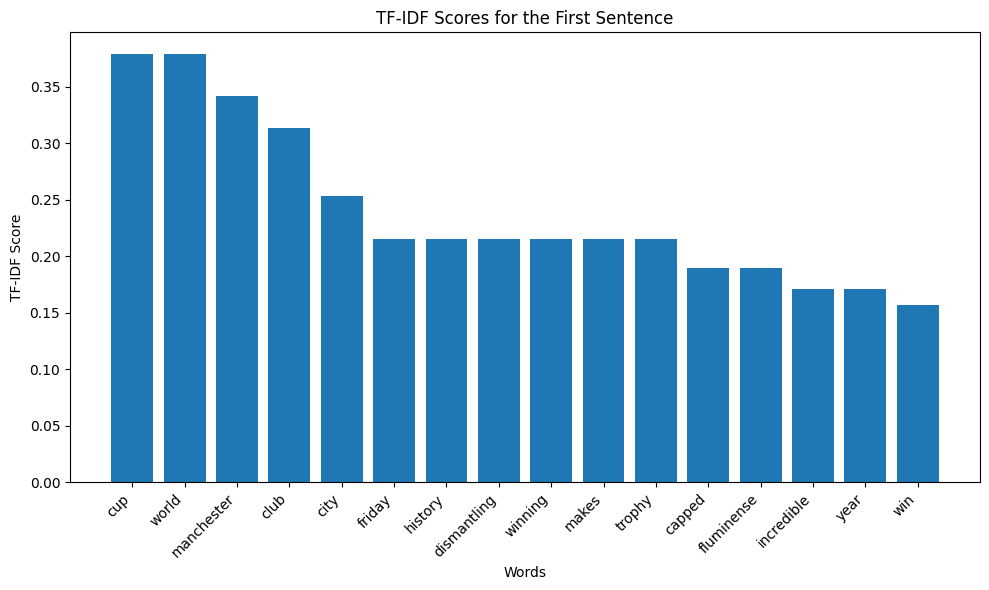


Top TF-IDF features in first sentence:
    Feature   TF-IDF
        cup 0.379003
      world 0.379003
 manchester 0.341991
       club 0.313283
       city 0.252815
     friday 0.215584
    history 0.215584
dismantling 0.215584
    winning 0.215584
      makes 0.215584
     trophy 0.215584
     capped 0.189501
 fluminense 0.189501
 incredible 0.170996
       year 0.170996
        win 0.156641


In [5]:
# Helper function to get TF-IDF scores for a specific sentence
def get_tfidf_for_sentence(features, sentence_index, feature_names):
    sentence_tfidf = features[sentence_index].toarray()[0]
    tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf})
    tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values('TF-IDF', ascending=False)
    return tfidf_df

# Visualize TF-IDF scores for the first sentence
first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

plt.figure(figsize=(10, 6))
plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.title(f"TF-IDF Scores for the First Sentence")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop TF-IDF features in first sentence:")
print(first_sentence_tfidf_df.to_string(index=False))

# Calculate TF-IDF Score per Sentence

In [6]:
# Variable initialization
sent_scores = []

# Calculate average TF-IDF score per sentence
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Threshold = average of all sentence scores
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0
print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.31514140188014117


In [7]:
# Manual TF-IDF calculation for the word 'city'
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

def calculate_idf(term, all_documents):
    num_docs_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    return math.log(len(all_documents) / num_docs_with_term) if num_docs_with_term > 0 else 0

target_word = 'city'
tfidf_scores = {}
for i, sent in enumerate(sent_token):
    tf = calculate_tf(target_word, sent)
    idf = calculate_idf(target_word, sent_token)
    tfidf_scores[f"Sentence {i+1}"] = tf * idf

print(f"TF-IDF Score for '{target_word}' in each sentence:")
for sent_num, score in tfidf_scores.items():
    print(f"{sent_num}: {score:.4f}")

overall_idf = calculate_idf(target_word, sent_token)
print(f"\nOverall IDF for '{target_word}': {overall_idf:.4f}")

# TF-IDF using sklearn for comparison
tfidf_col_index = list(feature_names).index(target_word) if target_word in feature_names else None
if tfidf_col_index is not None:
    print(f"\nTF-IDF Score for '{target_word}' using TfidfVectorizer:")
    for i, score in enumerate(features[:, tfidf_col_index].toarray().flatten()):
        print(f"Sentence {i+1}: {score:.4f}")

TF-IDF Score for 'city' in each sentence:
Sentence 1: 0.0636
Sentence 2: 0.0000
Sentence 3: 0.0456
Sentence 4: 0.0000
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0477
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0350
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0456
Sentence 15: 0.0000
Sentence 16: 0.0269
Sentence 17: 0.0000
Sentence 18: 0.0175
Sentence 19: 0.0000
Sentence 20: 0.0000

Overall IDF for 'city': 1.0498

TF-IDF Score for 'city' using TfidfVectorizer:
Sentence 1: 0.2528
Sentence 2: 0.0000
Sentence 3: 0.1672
Sentence 4: 0.0000
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.1878
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.1556
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.2086
Sentence 15: 0.0000
Sentence 16: 0.1596
Sentence 17: 0.0000
Sentence 18: 0.1308
Sentence 19: 0.0000
Sentence 20: 0.0000


# Get Summary Sentences

In [8]:
# Final summary initialization
final_summ = ""

# Include sentences with score >= threshold
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print("-", sent_token[index])

- “We’ve shown over the past 12 months we are the best team in the world.
- “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
- I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
- Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
- “As a manager it is what I am most proud of; that we are always there.
- The champion heads back to England where it faces a tough title defence in the Premier League.
- It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.


# Summarization Result

In [9]:
final_summ

' “We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range. “As a manager it is what I am most proud of; that we are always there. The champion heads back to England where it faces a tough title defence in the Premier League. It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.'